# Session 8 Step 4: (eta, lambda) grid analysis + E10 PLDM reference

Loads `outputs/runs/session8/grid_analysis.csv` (produced by
`scripts/session8_grid_analysis.py`). The grid covers 9 SIGReg+OBS
runs at three etas times three lambda_SIGReg values. E5 is the
Session 7 R3 anchor (eta=0.01, lambda=0.1), reused. Plus E10:
PLDM+OBS+BN with the paper-tuned Two-Rooms weights from
arXiv:2502.14819 Appendix J.2. Plus R1_S7 (the Session 7 PLDM with
default unit weights) as a comparator.

|                         | lambda=0.01 | lambda=0.1 (S7 default) | lambda=1.0 |
|-------------------------|-------------|-------------------------|------------|
| **eta=0.001**           | E1          | E2                      | E3         |
| **eta=0.01** (S7 default) | E4        | E5 (Session 7 R3 anchor) | E6        |
| **eta=0.1**             | E7          | E8                      | E9         |

Section 1 reports the SIGReg grid heatmaps and identifies (eta*, lambda*).
Section 2 reports the champion table (best SIGReg vs E5 Session 7 R3 vs
E10 paper-tuned PLDM vs R1 default-PLDM).
Section 3 reports the D53 / D53b decision strings.

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / 'configs' / 'splits').exists():
    REPO = REPO.parent
OUT = REPO / 'outputs' / 'runs' / 'session8'
df = pd.read_csv(OUT / 'grid_analysis.csv')
print(f'loaded {len(df)} rows across {df.code.nunique()} runs and {df.split.nunique()} splits')
df.head(11)

loaded 33 rows across 11 runs and 3 splits


,code,eta,lambda,kind,label,split,PR_all,PR_within,r2_z_c,r2_dyn_phase,r2_CL_future,r2_ct_baseline,delta
0,E1,0.001,0.01,jepa,E1 eta=0.001 lam=0.01,test_a,1.147542,2.160586,0.328227,0.289322,0.543855,0.738508,-0.194652
1,E1,0.001,0.01,jepa,E1 eta=0.001 lam=0.01,test_b,1.139338,2.089861,0.567723,0.257051,0.518302,0.718302,-0.200000
2,E1,0.001,0.01,jepa,E1 eta=0.001 lam=0.01,test_c,1.168644,1.687573,0.652111,0.610833,0.379991,0.350439,0.029552
3,E2,0.001,0.10,jepa,E2 eta=0.001 lam=0.1,test_a,2.348595,3.343516,0.551578,0.183518,0.851008,0.738508,0.112500
4,E2,0.001,0.10,jepa,E2 eta=0.001 lam=0.1,test_b,2.341623,2.403231,0.760863,0.530869,0.725766,0.718302,0.007463
5,E2,0.001,0.10,jepa,E2 eta=0.001 lam=0.1,test_c,2.173869,3.177681,0.785899,0.780384,0.764364,0.350439,0.413926
6,E3,0.001,1.00,jepa,E3 eta=0.001 lam=1.0,test_a,4.053743,2.783366,0.544256,0.333584,0.516852,0.738508,-0.221655
7,E3,0.001,1.00,jepa,E3 eta=0.001 lam=1.0,test_b,3.791827,3.073965,0.950425,0.658759,0.098624,0.718302,-0.619678
8,E3,0.001,1.00,jepa,E3 eta=0.001 lam=1.0,test_c,2.856155,2.935334,0.906968,0.753540,0.056527,0.350439,-0.293912
9,E4,0.010,0.01,jepa,E4 eta=0.01 lam=0.01,test_a,2.119043,4.488470,0.545154,0.496909,0.965020,0.738508,0.226513


## Section 1: SIGReg grid heatmaps and best operating point

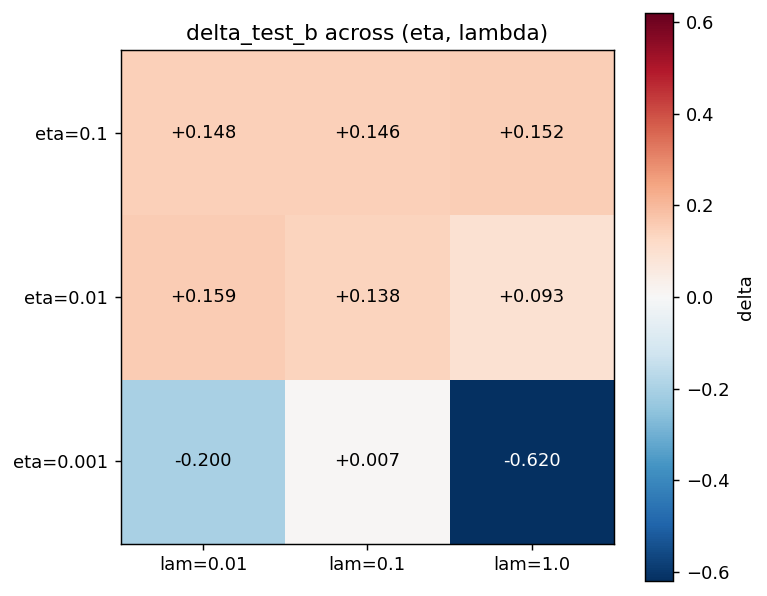

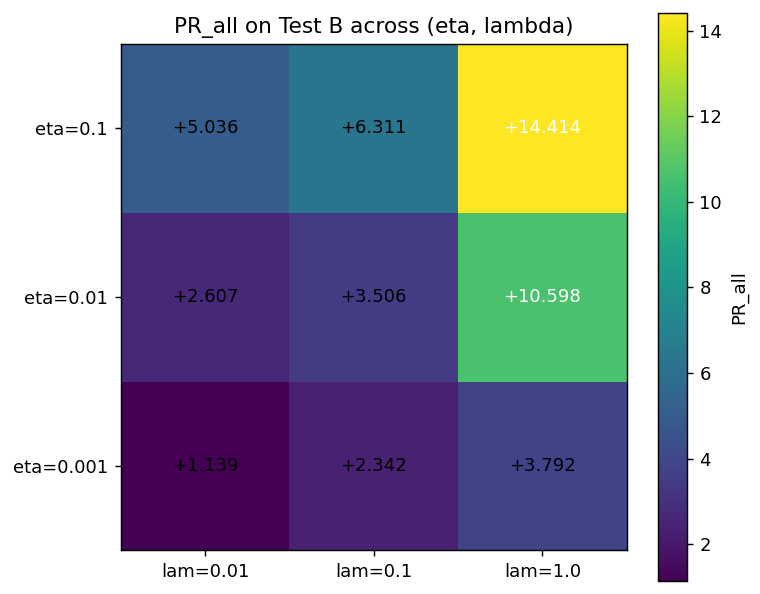

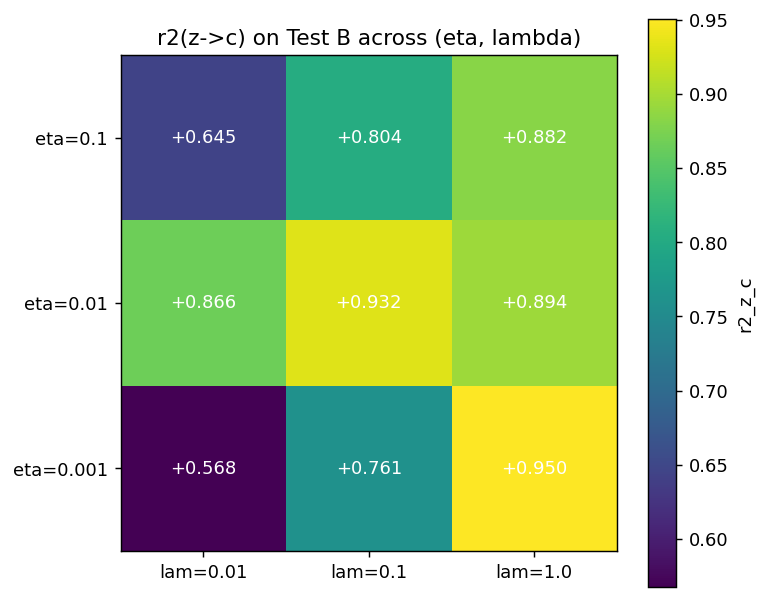

In [2]:
# Display the three precomputed heatmap PNGs
for fname in ['fig_grid_delta_b.png', 'fig_grid_pr_all.png', 'fig_grid_r2_z_c.png']:
    p = OUT / fname
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f'  MISSING: {p}')

In [3]:
best_p = OUT / 'best_grid_point.json'
if best_p.exists():
    with open(best_p) as f:
        best = json.load(f)
    print(f'Best SIGReg grid point: {best["code"]} '
          f'(eta={best["eta"]}, lambda={best["lambda"]}), delta_test_b={best["delta_b"]:+.3f}')
    print('This becomes the production (eta*, lambda*) for Step 5 d-sweep and Session 9.')
else:
    print('best_grid_point.json not yet written')

Best SIGReg grid point: E4 (eta=0.01, lambda=0.01), delta_test_b=+0.159
This becomes the production (eta*, lambda*) for Step 5 d-sweep and Session 9.


## Section 2: Champion table (Test B head-to-head)

In [4]:
champ = pd.read_csv(OUT / 'champion_table.csv')
champ.round(3)

,code,label,eta,lambda,PR_all,r2_z_c,r2_CL_future,r2_ct_baseline,delta
0,E4,E4 eta=0.01 lam=0.01,0.01,0.01,2.607,0.866,0.878,0.718,0.159
1,E5,E5 = Session 7 R3 anchor,0.01,0.10,3.506,0.932,0.856,0.718,0.138
2,E10,E10 PLDM paper-tuned,0.01,NaN,23.018,0.654,0.623,0.718,-0.095
3,R1_S7,R1 PLDM defaults (S7),0.01,NaN,18.335,0.955,0.715,0.718,-0.003


## Section 3: D53 and D53b decision strings

**D53 (SIGReg grid result):** report the (eta*, lambda*) identified in
Section 1 plus the grid shape (peaked interior, edge-peaked, or flat).

**D53b (E10 PLDM paper-tuned result):** compare E10's Test B delta to
the best SIGReg grid point. Three readings (from the plan):

- E10 delta_test_b < best SIGReg - 0.05: PLDM underperforms with proper
  tuning. D46 R3_WINS finding is robust to PLDM hyperparameter choice.
  No full PLDM sweep needed; paper claim 3 stands.
- E10 delta_test_b within 0.05 of best SIGReg: PLDM with tuning is
  competitive. Session 9 needs a proper PLDM hyperparameter sweep before
  the paper can claim either method is better.
- E10 delta_test_b > best SIGReg + 0.05: paper-tuned PLDM is the winner.
  Session 9 becomes a proper PLDM sweep; paper claim 3 inverts back
  toward the Session 6 D39 reading with the caveat that PLDM needs
  paper-tuned weights.

In [5]:
tb = df[df.split == 'test_b'].set_index('code')
if 'E10' in tb.index and best_p.exists():
    e10_delta = float(tb.loc['E10', 'delta'])
    best_delta = best['delta_b']
    gap = e10_delta - best_delta
    print(f'E10 PLDM paper-tuned Test B delta: {e10_delta:+.3f}')
    print(f'Best SIGReg grid point Test B delta: {best_delta:+.3f}')
    print(f'E10 - best SIGReg: {gap:+.3f}')
    if gap < -0.05:
        print('D53b reading: E10 underperforms with proper tuning. R3_WINS robust.')
    elif gap > 0.05:
        print('D53b reading: paper-tuned PLDM beats best SIGReg. Session 9 needs PLDM sweep.')
    else:
        print('D53b reading: paper-tuned PLDM competitive with best SIGReg. Session 9 needs proper PLDM sweep.')
else:
    print('E10 result not yet available')

E10 PLDM paper-tuned Test B delta: -0.095
Best SIGReg grid point Test B delta: +0.159
E10 - best SIGReg: -0.254
D53b reading: E10 underperforms with proper tuning. R3_WINS robust.
